In [16]:
# =======================
# PART 3: Fine-Tuning Using HuggingFace Phishing Dataset (FAST VERSION)
# =======================

import numpy as np
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

print("Device:", "GPU" if torch.cuda.is_available() else "CPU")


Device: CPU


In [17]:
# -----------------------------------------
# STEP 1: Load Dataset
# -----------------------------------------
hf_data = load_dataset(
    "json",
    data_files={"full": r"C:\Users\Sami\Documents\Semester 7\NLP\Assignment 3\combined_full.json"}
)

dataset = hf_data["full"]

# Split into train/test
dataset = dataset.train_test_split(test_size=0.2, seed=42)
train_hf = dataset["train"]
test_hf = dataset["test"]

print("Original Train size:", len(train_hf))
print("Original Test size:", len(test_hf))

# 🚀 Reduce dataset for speed
train_hf = train_hf.select(range(min(5000, len(train_hf))))
test_hf = test_hf.select(range(min(1000, len(test_hf))))

print("Reduced Train size:", len(train_hf))
print("Reduced Test size:", len(test_hf))


Original Train size: 697272
Original Test size: 174318
Reduced Train size: 5000
Reduced Test size: 1000


In [18]:
# -----------------------------------------
# STEP 2: Label Mapping
# -----------------------------------------
unique_labels = sorted(list(set(train_hf["label"])))
label2id = {label: i for i, label in enumerate(unique_labels)}
id2label = {i: label for label, i in label2id.items()}

train_hf = train_hf.map(lambda x: {"label": label2id[x["label"]]})
test_hf = test_hf.map(lambda x: {"label": label2id[x["label"]]})


Map: 100%|██████████| 1000/1000 [00:00<00:00, 4032.13 examples/s]


In [19]:
# -----------------------------------------
# STEP 3: Tokenization
# -----------------------------------------
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128   # 🔥 faster than 256
    )

train_hf = train_hf.map(tokenize, batched=True)
test_hf = test_hf.map(tokenize, batched=True)

train_hf = train_hf.remove_columns(["text"])
test_hf = test_hf.remove_columns(["text"])

train_hf = train_hf.with_format("torch")
test_hf = test_hf.with_format("torch")


Map: 100%|██████████| 1000/1000 [00:00<00:00, 2538.07 examples/s]


In [20]:
# -----------------------------------------
# STEP 4: Model
# -----------------------------------------
model_hf = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id
)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
# -----------------------------------------
# STEP 5: Metrics
# -----------------------------------------
def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


In [22]:
# -----------------------------------------
# STEP 6: TrainingArguments (FAST)
# -----------------------------------------
training_args = TrainingArguments(
    output_dir="hf_email_classifier",
    eval_strategy="epoch",
    save_strategy="no",               
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,               
    weight_decay=0.01,
    logging_steps=100,
    load_best_model_at_end=False,    
)

In [23]:
# -----------------------------------------
# STEP 7: Trainer + Train
# -----------------------------------------
trainer_hf = Trainer(
    model=model_hf,
    args=training_args,
    train_dataset=train_hf,
    eval_dataset=test_hf,
    compute_metrics=compute_metrics,
)

trainer_hf.train()
print("✓ HuggingFace Dataset Fine-Tuning Complete!")


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.212000,0.201371,0.939000,0.939057,0.939000,0.939020


✓ HuggingFace Dataset Fine-Tuning Complete!


In [25]:
# -----------------------------------------
# STEP 8: Evaluation 
# -----------------------------------------
preds_hf = trainer_hf.predict(test_hf)
y_true_hf = preds_hf.label_ids
y_pred_hf = np.argmax(preds_hf.predictions, axis=1)

# Fix: Convert label names to strings
target_names = [str(id2label[i]) for i in sorted(id2label.keys())]

print("\n===== PART 3: CLASSIFICATION REPORT =====")
print(classification_report(y_true_hf, y_pred_hf, target_names=target_names))


c:\Users\Sami\anaconda3\envs\cv\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)



===== PART 3: CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0       0.95      0.94      0.94       556
           1       0.93      0.93      0.93       444

    accuracy                           0.94      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.94      0.94      0.94      1000



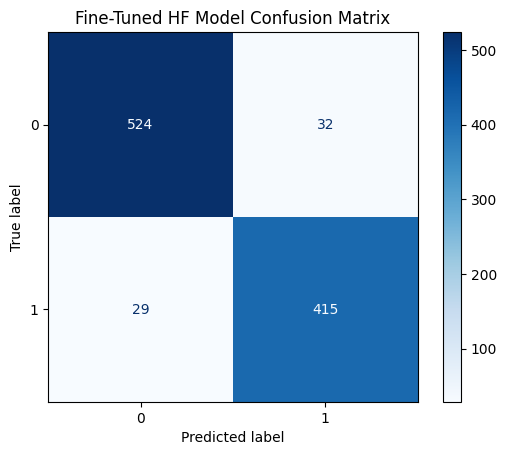

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Predictions from the fine-tuned HF trainer

# preds_hf = trainer_hf.predict(test_hf)

# y_true_hf = preds_hf.label_ids

# y_pred_hf = np.argmax(preds_hf.predictions, axis=1)

# Convert label IDs to string names

target_names = [str(id2label[i]) for i in sorted(id2label.keys())]

# Plot confusion matrix

cm = confusion_matrix(y_true_hf, y_pred_hf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Fine-Tuned HF Model Confusion Matrix")
plt.show()
